# PastureIQ — Weather & Market EDA (Mini-Project 1)

## Business problem

Small New Zealand hill-country sheep and beef farmers make stock buy/sell decisions largely on gut feel. Those decisions hinge on two things: **pasture** — how much feed the land is growing, driven by **weather** — and **price** — what the stock is worth at the works that month. There is no free, data-driven tool that helps a time-poor farmer weigh feed pressure against price to time a sale.

**PastureIQ** aims to fill that gap. This notebook is the first step: a clean exploration of the two data foundations the tool is built on — the **weather** across three North Island regions, and nearly ten years of **farmgate prices**.

## What this notebook does

1. Loads daily weather data (2015–2026) for three target regions and verifies its quality.
2. Explores the weather along three axes: **region vs region**, **time vs time**, **variable vs variable**.
3. Engineers agronomically meaningful features (growing degree days, water surplus, rolling ET0).
4. Explores nearly ten years of B+LNZ farmgate prices: seasonality, class differences, long-run trend.

## Questions this notebook answers

**Weather:**
1. **How do the three regions differ in their weather profile** — or are they effectively the same?
2. **When in the year does each region come under water stress** (evaporation outpacing rainfall)?
3. **Are dry years a local or a shared event** — does a drought hit one region or all three at once?

**Market:**
4. **Which months are historically the best and worst to sell** — is there a reliable seasonal pattern?
5. **How do the stock classes differ** in seasonality and volatility?

The conclusion returns to each by number.

## Data sources

- **Weather:** Open-Meteo (ERA5 archive), daily, CC BY 4.0 (*Weather data from Open-Meteo.com, CC BY 4.0*).
- **Prices:** Beef + Lamb New Zealand Economic Service — monthly farmgate prices, supplied directly for this non-commercial student project (2026). Cite B+LNZ; confirm reproduction permission for published figures.

## Regions

| Region | Area | File |
|---|---|---|
| Waikato | South Waikato / King Country hill country | `weather_waikato.csv` |
| Taranaki | South Taranaki / N. Whanganui hill country | `weather_taranaki.csv` |
| Auckland | West Auckland lifestyle blocks | `weather_auckland.csv` |

**A note on price units:** sheep are priced per head ($/hd), cattle per kg carcass weight (c/kg) — different scales, never plotted on one axis. Cross-class comparisons use each class indexed to its own average so units cancel.

---
## PART A — WEATHER

### Phase 1 — Setup and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# --- Adjust this path if your notebook is not run from the project root ---
DATA_DIR = '../data/raw/weather'

REGIONS = {
    'Waikato':  'weather_waikato.csv',
    'Taranaki': 'weather_taranaki.csv',
    'Auckland': 'weather_auckland.csv',
}

# Expected columns from the Open-Meteo pull (excluding the date column)
WEATHER_VARS = [
    'temperature_2m_max',
    'temperature_2m_min',
    'precipitation_sum',
    'et0_fao_evapotranspiration',
    'windspeed_10m_max',
]

In [2]:
def load_region(name, filename):
    """Load one region's weather CSV, parse dates, tag with region name."""
    df = pd.read_csv(f'{DATA_DIR}/{filename}')
    # Open-Meteo's date column is usually 'time' or 'date' — handle both.
    date_col = 'time' if 'time' in df.columns else 'date'
    df = df.rename(columns={date_col: 'date'})
    df['date'] = pd.to_datetime(df['date'])
    df['region'] = name
    return df

frames = {name: load_region(name, fn) for name, fn in REGIONS.items()}
weather = pd.concat(frames.values(), ignore_index=True)
weather.head()

,date,temperature_2m_max,temperature_2m_min,precipitation_sum,et0_fao_evapotranspiration,windspeed_10m_max,region
0,2015-01-01,20.8,14.0,5.6,4.83,19.7,Waikato
1,2015-01-02,20.7,13.4,0.0,3.57,12.6,Waikato
2,2015-01-03,23.7,11.9,0.2,4.70,9.8,Waikato
3,2015-01-04,23.0,13.3,0.3,4.50,13.0,Waikato
4,2015-01-05,22.4,13.2,0.0,5.06,14.0,Waikato


### Data quality check

Before any analysis, re-verify the claims from the data pull *inside the notebook*: row counts, date ranges, and missing values per region. Never trust an earlier verification blindly.

In [3]:
for name, df in frames.items():
    print(f'{name:10s} | rows: {len(df):5d} | '
          f'{df["date"].min().date()} to {df["date"].max().date()} | '
          f'missing values: {df[WEATHER_VARS].isna().sum().sum()}')

print('\nMissing values by column (all regions combined):')
print(weather[WEATHER_VARS].isna().sum())

Waikato    | rows:  4177 | 2015-01-01 to 2026-06-08 | missing values: 0
Taranaki   | rows:  4177 | 2015-01-01 to 2026-06-08 | missing values: 0
Auckland   | rows:  4177 | 2015-01-01 to 2026-06-08 | missing values: 0

Missing values by column (all regions combined):
temperature_2m_max            0
temperature_2m_min            0
precipitation_sum             0
et0_fao_evapotranspiration    0
windspeed_10m_max             0
dtype: int64


In [4]:
# Add calendar helper columns for time-based grouping
weather['year']  = weather['date'].dt.year
weather['month'] = weather['date'].dt.month

# NZ meteorological seasons (Southern Hemisphere)
season_map = {12: 'Summer', 1: 'Summer', 2: 'Summer',
              3: 'Autumn', 4: 'Autumn', 5: 'Autumn',
              6: 'Winter', 7: 'Winter', 8: 'Winter',
              9: 'Spring', 10: 'Spring', 11: 'Spring'}
weather['season'] = weather['month'].map(season_map)

weather[['date', 'region', 'year', 'month', 'season']].head()

,date,region,year,month,season
0,2015-01-01,Waikato,2015,1,Summer
1,2015-01-02,Waikato,2015,1,Summer
2,2015-01-03,Waikato,2015,1,Summer
3,2015-01-04,Waikato,2015,1,Summer
4,2015-01-05,Waikato,2015,1,Summer


In [5]:
# Summary statistics per region — a first feel for the data
weather.groupby('region')[WEATHER_VARS].describe().T

region                               Auckland     Taranaki      Waikato
temperature_2m_max         count  4177.000000  4177.000000  4177.000000
                           mean     17.936533    16.113431    17.403831
                           std       3.603731     4.227060     4.115502
                           min       7.800000     4.400000     5.900000
                           25%      14.900000    12.800000    14.000000
                           50%      17.700000    15.700000    17.000000
                           75%      20.900000    19.500000    20.800000
                           max      27.500000    29.200000    29.100000
temperature_2m_min         count  4177.000000  4177.000000  4177.000000
                           mean     12.614556     8.560259     9.473617
                           std       3.392024     4.003598     4.194698
                           min       2.800000    -4.200000    -2.400000
                           25%      10.200000     5.900000     6.600000
                           50%      12.600000     8.700000     9.600000
                           75%      15.300000    11.400000    12.600000
                           max      22.500000    19.700000    20.400000
precipitation_sum          count  4177.000000  4177.000000  4177.000000
                           mean      4.084726     3.711180     4.101867
                           std       7.905046     7.106853     8.429544
                           min       0.000000     0.000000     0.000000
                           25%       0.000000     0.000000     0.000000
                           50%       0.800000     0.700000     0.500000
                           75%       4.100000     4.300000     3.900000
                           max     108.300000    79.200000    88.100000
et0_fao_evapotranspiration count  4177.000000  4177.000000  4177.000000
                           mean      2.694898     2.215698     2.334891
                           std       1.292997     1.248165     1.316306
                           min       0.250000     0.230000     0.290000
                           25%       1.630000     1.160000     1.220000
                           50%       2.490000     1.920000     2.020000
                           75%       3.740000     3.110000     3.330000
                           max       6.200000     6.070000     6.430000
windspeed_10m_max          count  4177.000000  4177.000000  4177.000000
                           mean     23.165214    21.959253    20.282452
                           std       8.826504     7.739983     7.475452
                           min       5.500000     5.900000     4.600000
                           25%      16.300000    16.100000    14.700000
                           50%      22.000000    21.000000    19.400000
                           75%      28.800000    27.100000    25.000000
                           max      55.200000    56.100000    54.200000

> **Finding:** Waikato and Auckland are very similar. Taranaki has a larger range of temperatures but less rain. 

---
## Phase 2 — Exploratory analysis

Three comparison axes: region vs region, time vs time, variable vs variable.

### Axis 1 — Region vs region

How do the three regions differ in their core weather profile?

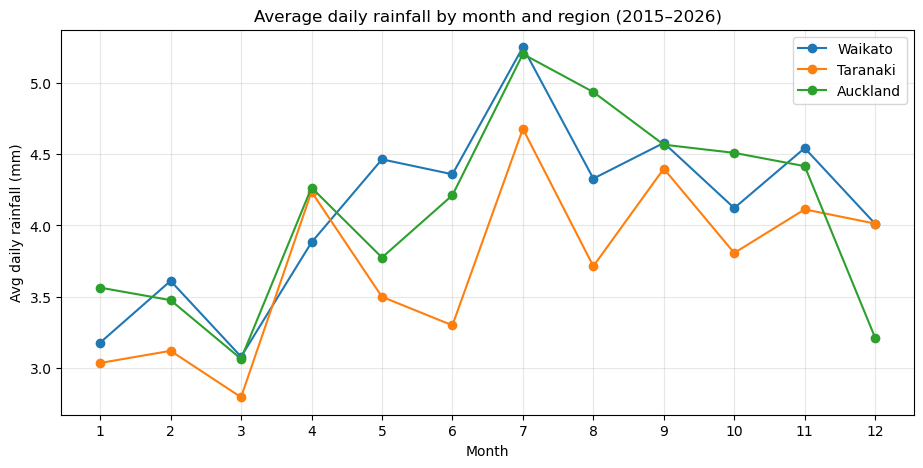

In [6]:
# Average monthly rainfall by region — the seasonal water-supply signal
monthly_rain = (weather.groupby(['region', 'month'])['precipitation_sum']
                       .mean().reset_index())

fig, ax = plt.subplots()
for name in REGIONS:
    sub = monthly_rain[monthly_rain['region'] == name]
    ax.plot(sub['month'], sub['precipitation_sum'], marker='o', label=name)
ax.set_xticks(range(1, 13))
ax.set_xlabel('Month')
ax.set_ylabel('Avg daily rainfall (mm)')
ax.set_title('Average daily rainfall by month and region (2015–2026)')
ax.legend()
plt.show()

In [7]:
# Annual average of each variable, side by side per region
region_means = weather.groupby('region')[WEATHER_VARS].mean()
region_means

,temperature_2m_max,temperature_2m_min,precipitation_sum,et0_fao_evapotranspiration,windspeed_10m_max
region,,,,,
Auckland,17.936533,12.614556,4.084726,2.694898,23.165214
Taranaki,16.113431,8.560259,3.711180,2.215698,21.959253
Waikato,17.403831,9.473617,4.101867,2.334891,20.282452


> **Finding :** Taranaki is the driest, while Auckland and Waikato share spots of the wettest, which tracks as they are closer and have more similar geography. 

In [8]:
# --- Question 1, tested formally ---
# The charts suggest Taranaki is drier than Auckland. Is that a real
# difference, or just noise? A two-sample t-test settles it.
#
# H0: no difference in mean daily rainfall between Taranaki and Auckland
# HA: there is a difference
# Significance level alpha = 0.05

alpha = 0.05
N = 200  # sample size per region

# Sample daily rainfall from each region (fixed seed for reproducibility)
taranaki_rain = weather.loc[weather['region'] == 'Taranaki', 'precipitation_sum'].sample(N, random_state=0)
auckland_rain = weather.loc[weather['region'] == 'Auckland', 'precipitation_sum'].sample(N, random_state=0)

print(f"Taranaki mean daily rainfall: {taranaki_rain.mean():.2f} mm")
print(f"Auckland mean daily rainfall: {auckland_rain.mean():.2f} mm")

Taranaki mean daily rainfall: 3.77 mm
Auckland mean daily rainfall: 3.22 mm


In [9]:
# Compute the t-statistic by hand (pooled standard deviation method)
var_t = taranaki_rain.var(ddof=1)
var_a = auckland_rain.var(ddof=1)
s = np.sqrt((var_t + var_a) / 2)                      # pooled std dev
t = (taranaki_rain.mean() - auckland_rain.mean()) / (s * np.sqrt(2/N))
dof = 2*N - 2                                          # degrees of freedom

# Two-tailed p-value
p = 2 * (1 - stats.t.cdf(abs(t), df=dof))

print(f"t-statistic (manual): {t:.4f}")
print(f"degrees of freedom:   {dof}")
print(f"p-value (manual):     {p:.4f}")

t-statistic (manual): 0.7251
degrees of freedom:   398
p-value (manual):     0.4688


In [10]:
# Cross-check against scipy's built-in t-test
t2, p2 = stats.ttest_ind(taranaki_rain, auckland_rain)
print(f"t-statistic (scipy):  {t2:.4f}")
print(f"p-value (scipy):      {p2:.4f}")

if p2 < alpha:
    print(f"\np < {alpha}: reject H0 — the regions DO differ significantly in mean rainfall.")
else:
    print(f"\np >= {alpha}: fail to reject H0 — no significant difference; the regions are statistically alike.")

t-statistic (scipy):  0.7251
p-value (scipy):      0.4688

p >= 0.05: fail to reject H0 — no significant difference; the regions are statistically alike.


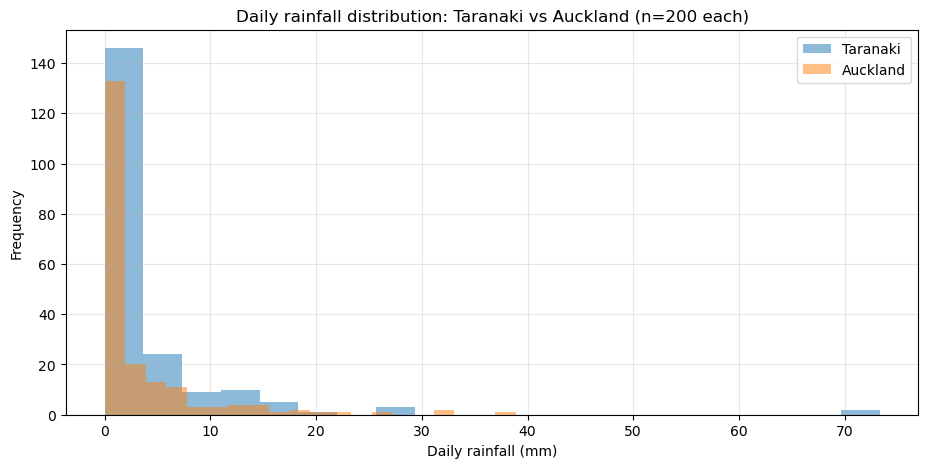

In [11]:
# Visualise the two distributions being compared
plt.hist(taranaki_rain, bins=20, alpha=0.5, label='Taranaki')
plt.hist(auckland_rain, bins=20, alpha=0.5, label='Auckland')
plt.xlabel('Daily rainfall (mm)')
plt.ylabel('Frequency')
plt.title(f'Daily rainfall distribution: Taranaki vs Auckland (n={N} each)')
plt.legend()
plt.show()

> **Finding:** The test does not reject the null hypothesis.The test found no significant rainfall difference between Taranaki and Auckland, so for rainfall they can be treated similarly — though they still differ in temperature and growing-season length.

### Axis 2 — Time vs time

Seasonal patterns and year-to-year variation. This is where drought years and wet years show up.

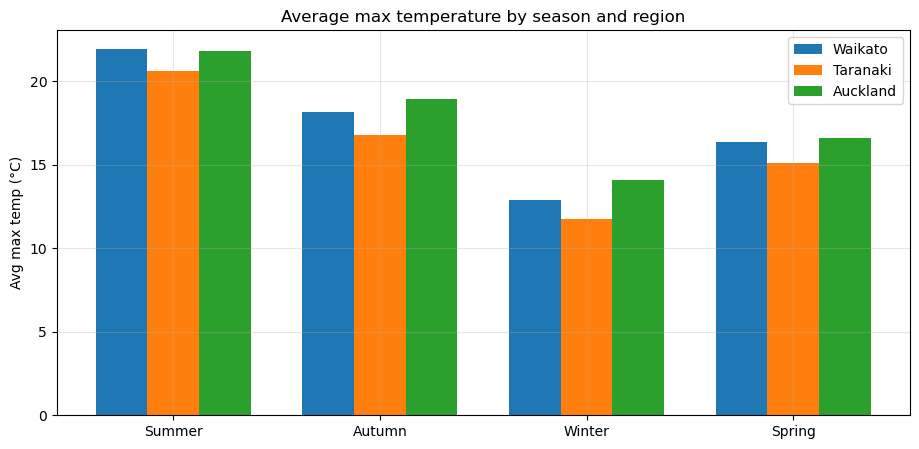

In [12]:
# Seasonal temperature pattern (max temp) per region
season_order = ['Summer', 'Autumn', 'Winter', 'Spring']
seasonal_temp = (weather.groupby(['region', 'season'])['temperature_2m_max']
                        .mean().reset_index())

fig, ax = plt.subplots()
width = 0.25
x = np.arange(len(season_order))
for i, name in enumerate(REGIONS):
    sub = seasonal_temp[seasonal_temp['region'] == name].set_index('season').reindex(season_order)
    ax.bar(x + i*width, sub['temperature_2m_max'], width, label=name)
ax.set_xticks(x + width)
ax.set_xticklabels(season_order)
ax.set_ylabel('Avg max temp (°C)')
ax.set_title('Average max temperature by season and region')
ax.legend()
plt.show()

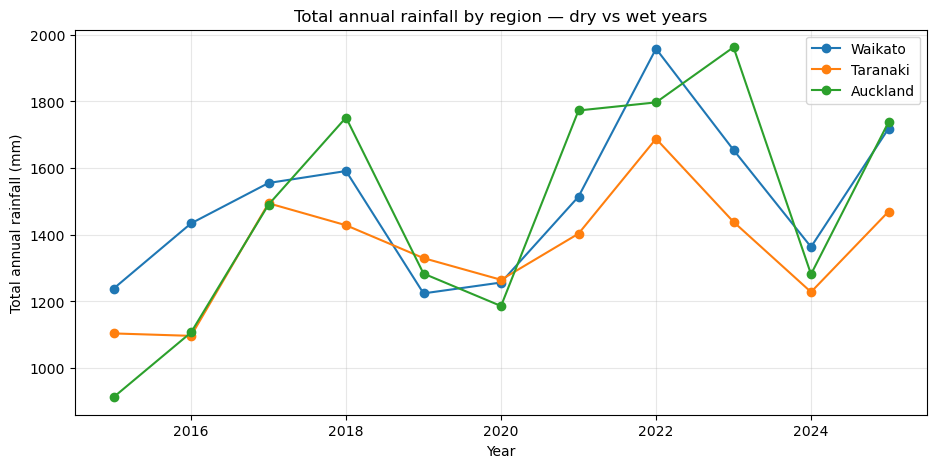

In [13]:
# Year-to-year total rainfall — spot the dry years and the wet years
annual_rain = (weather.groupby(['region', 'year'])['precipitation_sum']
                      .sum().reset_index())
# Drop partial years if 2026 is incomplete
full_years = annual_rain[annual_rain['year'] < weather['year'].max()]

fig, ax = plt.subplots()
for name in REGIONS:
    sub = full_years[full_years['region'] == name]
    ax.plot(sub['year'], sub['precipitation_sum'], marker='o', label=name)
ax.set_xlabel('Year')
ax.set_ylabel('Total annual rainfall (mm)')
ax.set_title('Total annual rainfall by region — dry vs wet years')
ax.legend()
plt.show()

> **Finding :** Clear year-to-year swings all three regions share: 2019–2020 were dry years across the board, 2022–2023 were wet. Auckland (green) is the most volatile — lowest in 2015, highest in 2022/2023. Taranaki consistently lowest in wet years

### Axis 3 — Variable vs variable

Relationships between the weather variables. The key one for pasture: rainfall (water in) vs ET0 (water demand out). When ET0 exceeds rainfall, the land is drying.

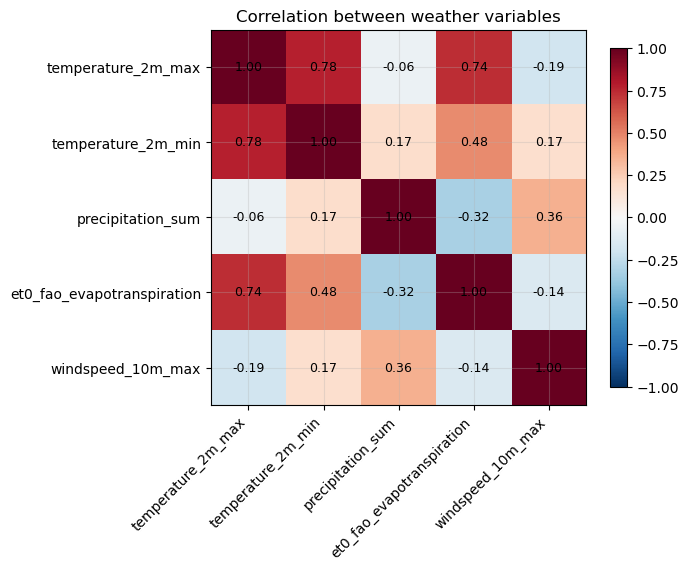

In [14]:
# Correlation matrix of the weather variables (all regions combined)
corr = weather[WEATHER_VARS].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(WEATHER_VARS)))
ax.set_yticks(range(len(WEATHER_VARS)))
ax.set_xticklabels(WEATHER_VARS, rotation=45, ha='right')
ax.set_yticklabels(WEATHER_VARS)
for i in range(len(WEATHER_VARS)):
    for j in range(len(WEATHER_VARS)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Correlation between weather variables')
plt.tight_layout()
plt.show()

> **Finding:** The data behaves the way physics says it should, which validates the dataset's integrity. Min and max temperature have a high correlation (0.78). Evapotranspiration and precipitation have a negative correlation (-0.32). Wind speed has the least correlation with other variables. 

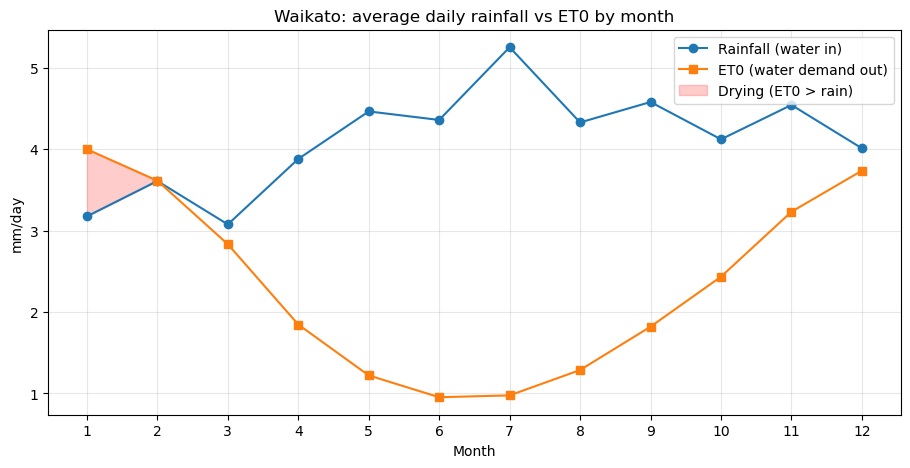

In [15]:
# Monthly rainfall vs ET0 for one region — the core pasture water-balance signal
focus = 'Waikato'
sub = weather[weather['region'] == focus]
monthly = sub.groupby('month')[['precipitation_sum', 'et0_fao_evapotranspiration']].mean()

fig, ax = plt.subplots()
ax.plot(monthly.index, monthly['precipitation_sum'], marker='o', label='Rainfall (water in)')
ax.plot(monthly.index, monthly['et0_fao_evapotranspiration'], marker='s', label='ET0 (water demand out)')
ax.fill_between(monthly.index, monthly['precipitation_sum'],
                monthly['et0_fao_evapotranspiration'],
                where=(monthly['et0_fao_evapotranspiration'] > monthly['precipitation_sum']),
                alpha=0.2, color='red', label='Drying (ET0 > rain)')
ax.set_xticks(range(1, 13))
ax.set_xlabel('Month')
ax.set_ylabel('mm/day')
ax.set_title(f'{focus}: average daily rainfall vs ET0 by month')
ax.legend()
plt.show()

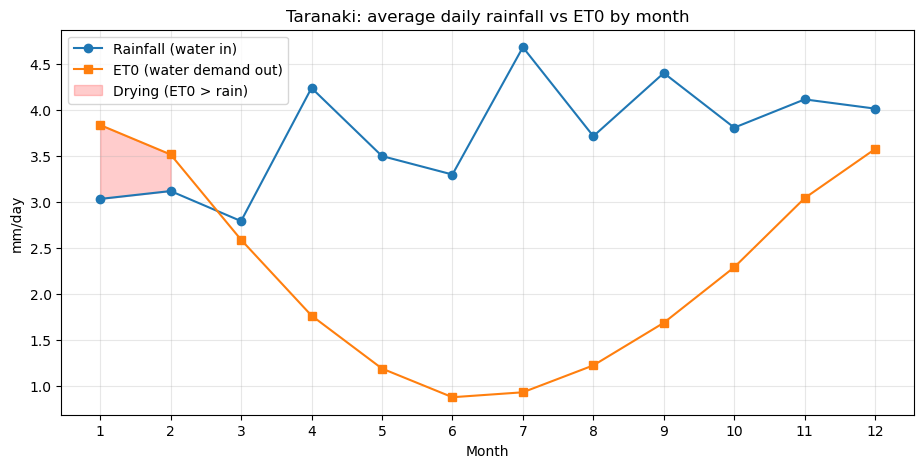

In [16]:
# Monthly rainfall vs ET0 for one region — the core pasture water-balance signal
focus = 'Taranaki'
sub = weather[weather['region'] == focus]
monthly = sub.groupby('month')[['precipitation_sum', 'et0_fao_evapotranspiration']].mean()

fig, ax = plt.subplots()
ax.plot(monthly.index, monthly['precipitation_sum'], marker='o', label='Rainfall (water in)')
ax.plot(monthly.index, monthly['et0_fao_evapotranspiration'], marker='s', label='ET0 (water demand out)')
ax.fill_between(monthly.index, monthly['precipitation_sum'],
                monthly['et0_fao_evapotranspiration'],
                where=(monthly['et0_fao_evapotranspiration'] > monthly['precipitation_sum']),
                alpha=0.2, color='red', label='Drying (ET0 > rain)')
ax.set_xticks(range(1, 13))
ax.set_xlabel('Month')
ax.set_ylabel('mm/day')
ax.set_title(f'{focus}: average daily rainfall vs ET0 by month')
ax.legend()
plt.show()

> **Finding:** The red drying wedge appears only in mid-summer (months 1–2), where ET0 briefly exceeds rain. Waikato is rarely in true water deficit on these averages — but summer is the pinch point, exactly when pasture stress and feed tightening happen.
Taranaki has more variance in Rainfall and a slightly larger drying range.

---
## Phase 3 — Feature engineering

Three agronomically meaningful features derived from the raw weather. These preview the pasture-growth model in the next phase — they are the inputs that drive grass growth.

1. **Growing Degree Days (GDD)** — accumulated warmth above a base temperature; a standard driver of plant growth.
2. **Rainfall deficit** — rainfall minus ET0; negative means the land is losing more water than it gains.
3. **Rolling ET0 (7-day)** — smooths daily noise to show sustained drying pressure.

In [17]:
BASE_TEMP = 5.0  # °C — common base for temperate pasture grasses

def add_features(df):
    df = df.sort_values('date').copy()
    # 1. Growing degree days: mean daily temp above base, floored at 0
    mean_temp = (df['temperature_2m_max'] + df['temperature_2m_min']) / 2
    df['gdd'] = (mean_temp - BASE_TEMP).clip(lower=0)
    # 2. Daily rainfall deficit (water in minus water demand)
    df['rain_deficit'] = df['precipitation_sum'] - df['et0_fao_evapotranspiration']
    # 3. 7-day rolling ET0 (sustained drying pressure)
    df['et0_7day'] = df['et0_fao_evapotranspiration'].rolling(7, min_periods=1).mean()
    return df

# Apply per region and recombine (version-robust — keeps the 'region' column intact)
weather = pd.concat([add_features(g) for _, g in weather.groupby('region')], ignore_index=True)
weather[['date', 'region', 'gdd', 'rain_deficit', 'et0_7day']].head()

,date,region,gdd,rain_deficit,et0_7day
0,2015-01-01,Auckland,11.70,-3.24,5.040000
1,2015-01-02,Auckland,12.65,-5.39,5.215000
2,2015-01-03,Auckland,12.95,-4.52,4.983333
3,2015-01-04,Auckland,13.40,-5.41,5.090000
4,2015-01-05,Auckland,14.45,-4.87,5.046000


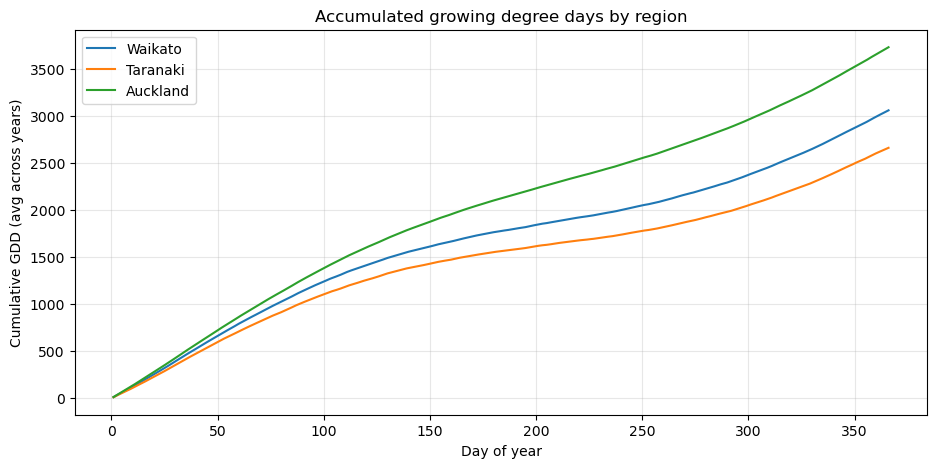

In [18]:
# Cumulative GDD through the year, per region — the warmth available for grass growth
weather['doy'] = weather['date'].dt.dayofyear
gdd_by_doy = (weather.groupby(['region', 'doy'])['gdd'].mean()
                     .groupby(level=0).cumsum().reset_index())

fig, ax = plt.subplots()
for name in REGIONS:
    sub = gdd_by_doy[gdd_by_doy['region'] == name]
    ax.plot(sub['doy'], sub['gdd'], label=name)
ax.set_xlabel('Day of year')
ax.set_ylabel('Cumulative GDD (avg across years)')
ax.set_title('Accumulated growing degree days by region')
ax.legend()
plt.show()

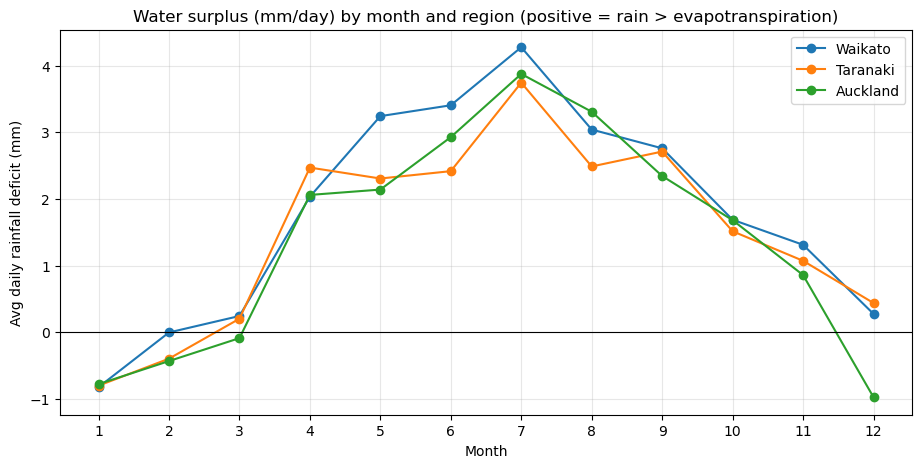

In [19]:
# Monthly average rainfall deficit per region — when is each region in water deficit?
monthly_deficit = (weather.groupby(['region', 'month'])['rain_deficit']
                          .mean().reset_index())

fig, ax = plt.subplots()
for name in REGIONS:
    sub = monthly_deficit[monthly_deficit['region'] == name]
    ax.plot(sub['month'], sub['rain_deficit'], marker='o', label=name)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xticks(range(1, 13))
ax.set_xlabel('Month')
ax.set_ylabel('Avg daily rainfall deficit (mm)')
ax.set_title('Water surplus (mm/day) by month and region (positive = rain > evapotranspiration)')
ax.legend()
plt.show()

> **Finding :** Auckland accumulates warmth fastest (green, top), Taranaki slowest (orange, bottom), Waikato between — consistent with the temperature chart. The curves fan apart over the year, so by year-end Auckland has ~3,700 GDD vs Taranaki ~2,650. Interpretation: Auckland has the longest effective growing window; Taranaki the shortest — meaning more potential pasture-growth days up north, a genuine region-level difference that matters for stocking

---
## PART B — MARKET PRICES

Weather tells us when pasture tightens. Price tells us when stock is worth selling. PastureIQ's value is combining them: feed pressure **plus** a strong price is a clear sell signal; feed pressure plus a weak price is a genuine trade-off to surface.

Data: B+LNZ monthly farmgate prices, Oct 2016 – May 2026, seven classes (sheep in $/hd, cattle in c/kg). (YM, M, P differnt manufacturing grades for meat)

In [20]:
# --- Market price data ---
prices = pd.read_csv('../data/raw/market/blnz_farmgate_prices.csv', parse_dates=['date'])
prices['month'] = prices['date'].dt.month
prices['year'] = prices['date'].dt.year

LABELS = {
    'ym_lamb': 'YM Lamb', 'all_grades_lamb': 'All Grades Lamb',
    'mx1_mutton': 'MX1 Mutton', 'all_grades_mutton': 'All Grades Mutton',
    'm_cow_170_195kg': 'M Cow (170-195kg)',
    'p_steer_heifer_270_295kg': 'P Steer & Heifer (270-295kg)',
    'm_bull_270_295kg': 'M Bull (270-295kg)',
}
SHEEP = ['ym_lamb', 'all_grades_lamb', 'mx1_mutton', 'all_grades_mutton']   # $/hd
CATTLE = ['m_cow_170_195kg', 'p_steer_heifer_270_295kg', 'm_bull_270_295kg'] # c/kg

print(f"Rows: {len(prices)}")
print(f"Date range: {prices['date'].min().date()} to {prices['date'].max().date()}")
print(f"Missing prices: {prices['price'].isna().sum()}")
print('\nMonths per series:')
print(prices.groupby('series').size().rename(index=LABELS))

Rows: 809
Date range: 2016-10-01 to 2026-05-01
Missing prices: 0

Months per series:
series
All Grades Lamb                 116
All Grades Mutton               116
M Bull (270-295kg)              115
M Cow (170-195kg)               115
MX1 Mutton                      116
P Steer & Heifer (270-295kg)    115
YM Lamb                         116
dtype: int64


In [21]:
# Wide format + summary (mean/std/min/max per class)
wide = prices.pivot_table(index='date', columns='series', values='price')
LSC_desc = wide.describe().T[['mean','std','min','max']].rename(index=LABELS)
LSC_desc

,mean,std,min,max
series,,,,
All Grades Lamb,151.522241,32.940930,92.48,240.03
All Grades Mutton,108.547069,30.369603,46.55,167.44
M Bull (270-295kg),597.963478,114.859317,469.20,957.50
M Cow (170-195kg),443.393043,100.794155,312.70,722.00
MX1 Mutton,89.263190,23.704039,40.97,133.67
P Steer & Heifer (270-295kg),608.993043,113.008927,467.10,948.60
YM Lamb,123.676207,22.292074,83.11,180.72


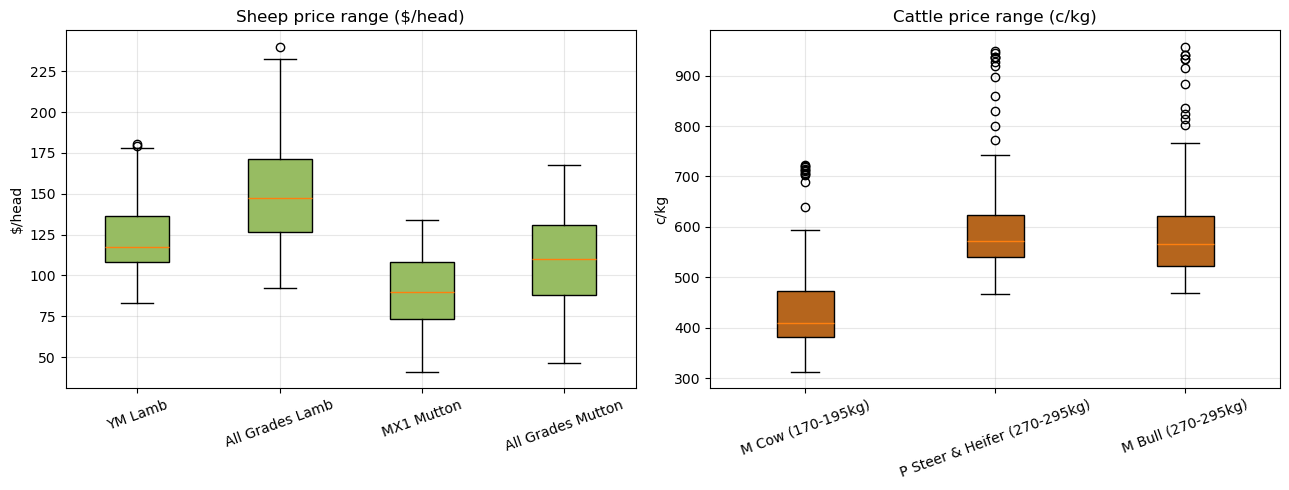

In [22]:
# Box plots — price range and outliers by class.
# Sheep ($/hd) and cattle (c/kg) plotted separately because the units differ.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Sheep panel ($/head) ---
sheep_data = [prices[prices['series'] == s]['price'].values for s in SHEEP]
bp1 = ax1.boxplot(sheep_data, tick_labels=[LABELS[s] for s in SHEEP],
                  patch_artist=True, showfliers=True)
for box in bp1['boxes']:
    box.set_facecolor('#97BC62')
ax1.set_title('Sheep price range ($/head)')
ax1.set_ylabel('$/head')
ax1.tick_params(axis='x', rotation=20)

# --- Cattle panel (c/kg) ---
cattle_data = [prices[prices['series'] == s]['price'].values for s in CATTLE]
bp2 = ax2.boxplot(cattle_data, tick_labels=[LABELS[s] for s in CATTLE],
                  patch_artist=True, showfliers=True)
for box in bp2['boxes']:
    box.set_facecolor('#B5651D')
ax2.set_title('Cattle price range (c/kg)')
ax2.set_ylabel('c/kg')
ax2.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

> **Finding:** Cattle show the widest raw range, but that's partly because they're priced in c/kg — larger numbers mean larger absolute spread. Relative volatility (CV, below) tells the truer story.

### Question 4a — Long-run price trend (last decade)

Sheep and cattle plotted separately because of the unit difference.

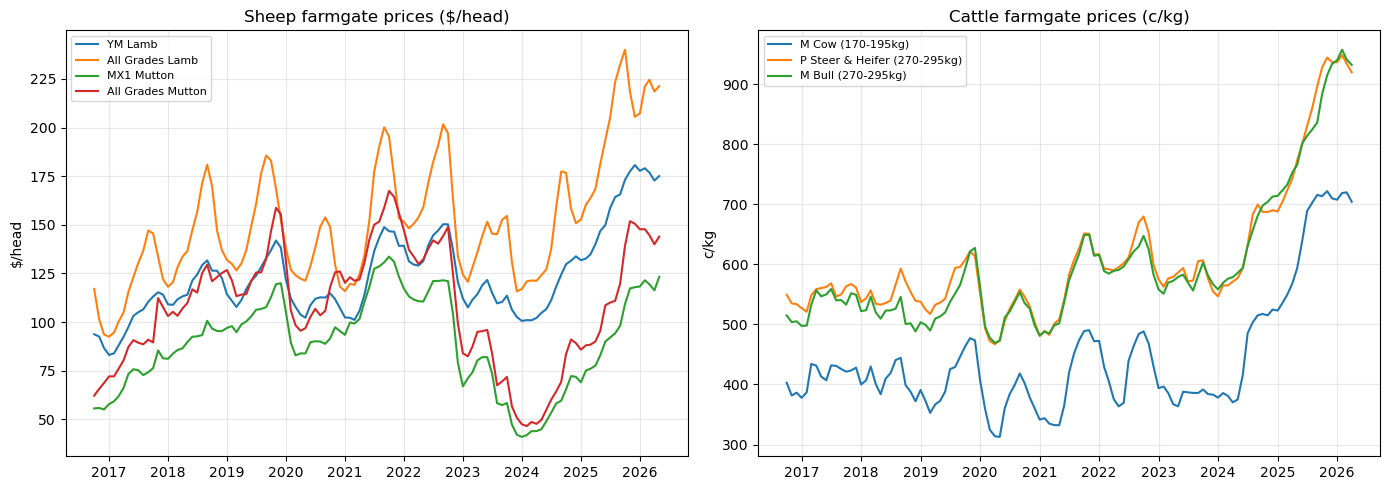

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for s in SHEEP:
    d = wide[s].dropna(); ax1.plot(d.index, d.values, label=LABELS[s])
ax1.set_title('Sheep farmgate prices ($/head)'); ax1.set_ylabel('$/head'); ax1.legend(fontsize=8)
for s in CATTLE:
    d = wide[s].dropna(); ax2.plot(d.index, d.values, label=LABELS[s])
ax2.set_title('Cattle farmgate prices (c/kg)'); ax2.set_ylabel('c/kg'); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

> **Finding:** steadily fluctuating prices around a mean for both sheep and beef from 2018 - 2023. for sheep a big dip in prices in 2024 and now in 2026 at its highest. beef did not have the dip but now has the all-time high in price as well. 

### Question 4 — Best and worst months to sell (seasonality)

Averaging each month across all years reveals the seasonal pattern. This monthly average becomes the **price baseline** in MP3 (a price is 'high' or 'low' relative to its own seasonal norm).

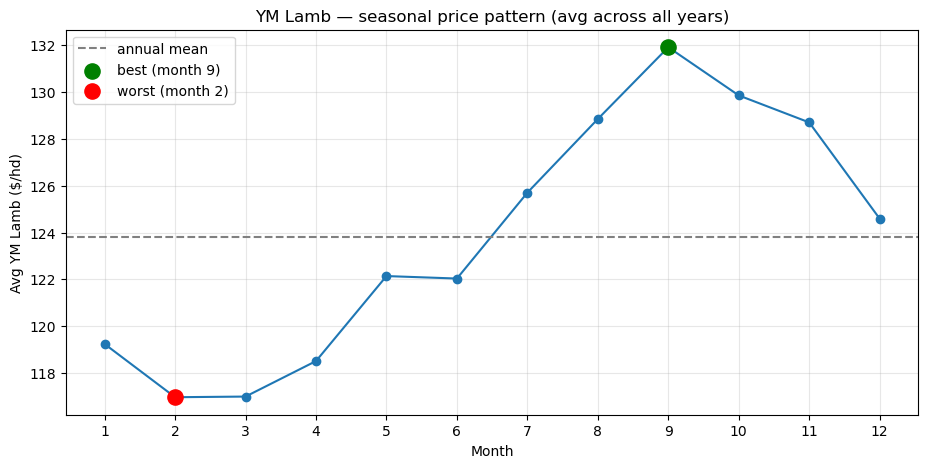

Best month to sell YM lamb:  month 9 ($132/hd)
Worst month to sell YM lamb: month 2 ($117/hd)
Seasonal swing: $15/hd (12% of mean)


In [24]:
def seasonal_avg(series_name):
    d = prices[prices['series'] == series_name]
    return d.groupby('month')['price'].mean()

lamb = seasonal_avg('ym_lamb')
fig, ax = plt.subplots()
ax.plot(lamb.index, lamb.values, marker='o', color='C0')
ax.axhline(lamb.mean(), color='grey', ls='--', label='annual mean')
best, worst = lamb.idxmax(), lamb.idxmin()
ax.scatter([best],[lamb[best]], color='green', s=120, zorder=5, label=f'best (month {best})')
ax.scatter([worst],[lamb[worst]], color='red', s=120, zorder=5, label=f'worst (month {worst})')
ax.set_xticks(range(1,13)); ax.set_xlabel('Month'); ax.set_ylabel('Avg YM Lamb ($/hd)')
ax.set_title('YM Lamb — seasonal price pattern (avg across all years)'); ax.legend()
plt.show()
print(f'Best month to sell YM lamb:  month {best} (${lamb[best]:.0f}/hd)')
print(f'Worst month to sell YM lamb: month {worst} (${lamb[worst]:.0f}/hd)')
print(f'Seasonal swing: ${lamb.max()-lamb.min():.0f}/hd ({100*(lamb.max()-lamb.min())/lamb.mean():.0f}% of mean)')

> **Finding:** Best month is September to sell and worst is February. Tie to supply: most lambs hit the works Oct–Dec (B+LNZ Lamb Crop Report), so prices typically bottom then and peak off-season. 

### The lamb→hogget timing trap

A lamb reclassifies to hogget around 12 months (first adult incisors), dropping out of premium lamb pricing. Comparing lamb vs mutton seasonal *shape* (indexed to each own mean, so units cancel) shows the timing stakes.

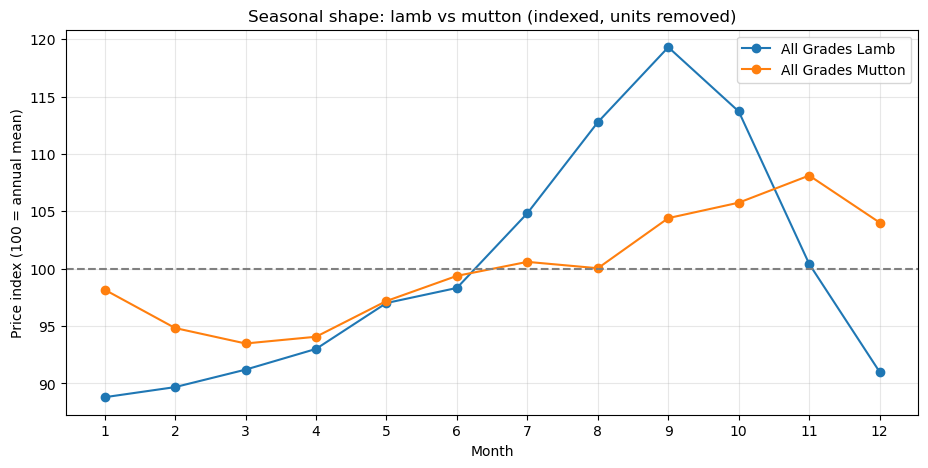

In [25]:
def indexed_seasonal(series_name):
    s = seasonal_avg(series_name); return s / s.mean() * 100

fig, ax = plt.subplots()
for s in ['all_grades_lamb','all_grades_mutton']:
    idx = indexed_seasonal(s); ax.plot(idx.index, idx.values, marker='o', label=LABELS[s])
ax.axhline(100, color='grey', ls='--'); ax.set_xticks(range(1,13))
ax.set_xlabel('Month'); ax.set_ylabel('Price index (100 = annual mean)')
ax.set_title('Seasonal shape: lamb vs mutton (indexed, units removed)'); ax.legend()
plt.show()

> **Findings:** Mutton has a much flatter price curve and a slight of set peak in November. Lamb has a drastic peak in September with a stark fall of in December with a over 20$ difference per head. It will have a big indicator on the sale indicator depending on the time of year

In [28]:
# --- Model-ready feature: price vs seasonal baseline ---
# For each class, express every month's price as % above/below that class's
# seasonal average for that calendar month. This is the core market signal
# PastureIQ will use: "is today's price high or low for THIS time of year?"
# (FORMULAS.md Group D). Computed per class so the $/hd vs c/kg units never mix.

# Seasonal average per class per calendar month (the baseline)
seasonal_baseline = prices.groupby(['series', 'month'])['price'].transform('mean')

# The feature: signed % deviation from the class's own seasonal norm
prices['price_vs_seasonal'] = (prices['price'] - seasonal_baseline) / seasonal_baseline * 100

# Sanity check: by construction each class's mean deviation is ~0
print("Mean price_vs_seasonal by class (should be ~0):")
print(prices.groupby('series')['price_vs_seasonal'].mean().round(2).rename(index=LABELS))

prices[['date', 'series', 'price', 'price_vs_seasonal']].head()

Mean price_vs_seasonal by class (should be ~0):
series
All Grades Lamb                 0.0
All Grades Mutton              -0.0
M Bull (270-295kg)             -0.0
M Cow (170-195kg)              -0.0
MX1 Mutton                     -0.0
P Steer & Heifer (270-295kg)    0.0
YM Lamb                         0.0
Name: price_vs_seasonal, dtype: float64


,date,series,price,price_vs_seasonal
0,2016-10-01,all_grades_lamb,117.03,-32.275873
1,2016-11-01,all_grades_lamb,101.50,-33.489289
2,2016-12-01,all_grades_lamb,93.63,-32.300818
3,2017-01-01,all_grades_lamb,92.48,-31.473454
4,2017-02-01,all_grades_lamb,94.65,-30.555046


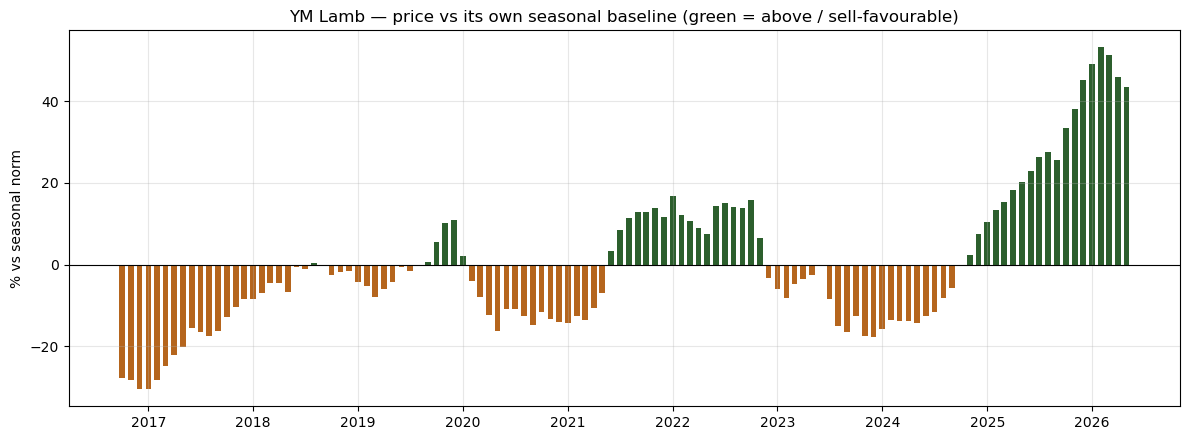

In [29]:
# Visualise the signal for one class: months above the seasonal norm (sell-favourable)
# vs below (weak). Green = price above its seasonal average, red = below.
focus = 'ym_lamb'
d = prices[prices['series'] == focus].sort_values('date')

fig, ax = plt.subplots(figsize=(12, 4.5))
colors = ['#2C5F2D' if v >= 0 else '#B5651D' for v in d['price_vs_seasonal']]
ax.bar(d['date'], d['price_vs_seasonal'], color=colors, width=20)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('% vs seasonal norm')
ax.set_title(f'{LABELS[focus]} — price vs its own seasonal baseline (green = above / sell-favourable)')
plt.tight_layout()
plt.show()

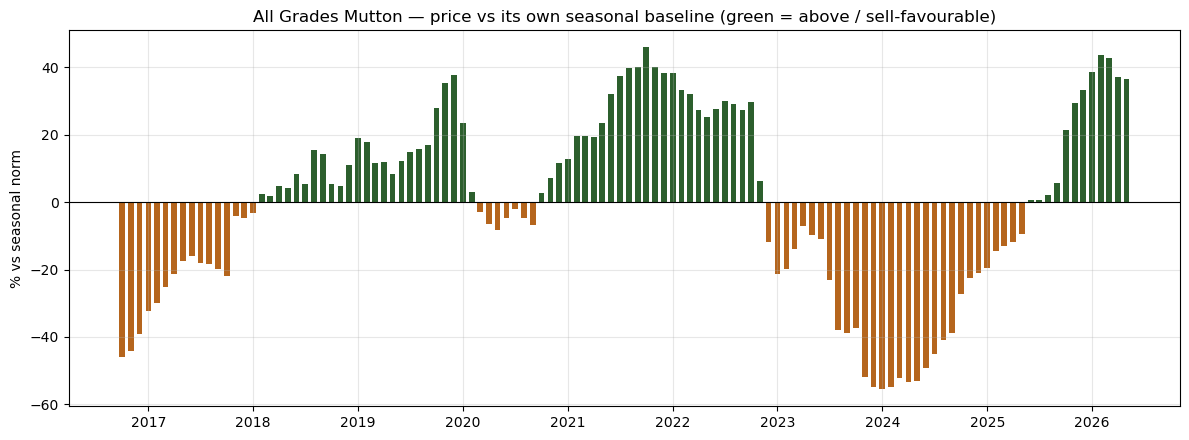

In [30]:
# Visualise the signal for one class: months above the seasonal norm (sell-favourable)
# vs below (weak). Green = price above its seasonal average, red = below.
focus = 'all_grades_mutton'
d = prices[prices['series'] == focus].sort_values('date')

fig, ax = plt.subplots(figsize=(12, 4.5))
colors = ['#2C5F2D' if v >= 0 else '#B5651D' for v in d['price_vs_seasonal']]
ax.bar(d['date'], d['price_vs_seasonal'], color=colors, width=20)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('% vs seasonal norm')
ax.set_title(f'{LABELS[focus]} — price vs its own seasonal baseline (green = above / sell-favourable)')
plt.tight_layout()
plt.show()

> **Finding:** The signal turns strongly positive in the recent record-price
> period (2025–26) and negative through the 2024 dip — showing the feature captures both
> the seasonal position AND the wider trend. This is the number that feeds the buy/sell
> score: a high positive value = price well above its seasonal norm = a sell-favorable
> month.

### Question 5 — How the classes differ (seasonality + volatility)

All classes on one indexed axis (units removed), then a volatility ranking.

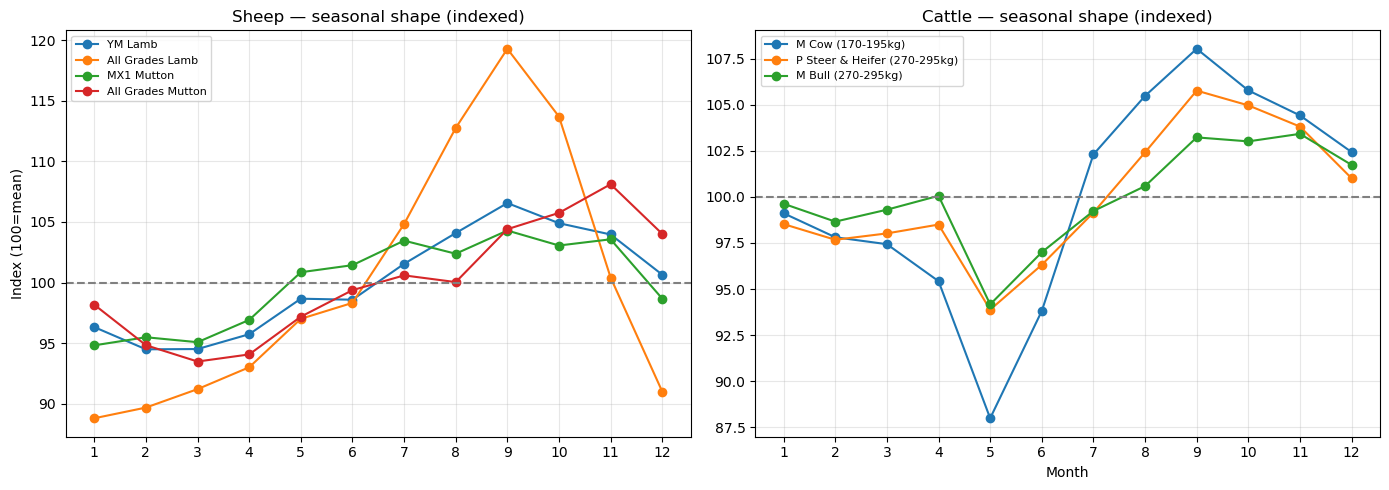

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for s in SHEEP:
    idx = indexed_seasonal(s); ax1.plot(idx.index, idx.values, marker='o', label=LABELS[s])
ax1.axhline(100, color='grey', ls='--'); ax1.set_xticks(range(1,13))
ax1.set_title('Sheep — seasonal shape (indexed)'); ax1.set_ylabel('Index (100=mean)'); ax1.legend(fontsize=8)
for s in CATTLE:
    idx = indexed_seasonal(s); ax2.plot(idx.index, idx.values, marker='o', label=LABELS[s])
ax2.axhline(100, color='grey', ls='--'); ax2.set_xticks(range(1,13))
ax2.set_title('Cattle — seasonal shape (indexed)'); ax2.set_xlabel('Month'); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Findings:** Seasonal all grade lamb and M Cows have the largest spike and drop. The rest of the sheep have a pretty small curve throughout th year while cattle follows the dip and spike but to a lesser extreme. Price signal depends more on the season for lambs and cattle depending.

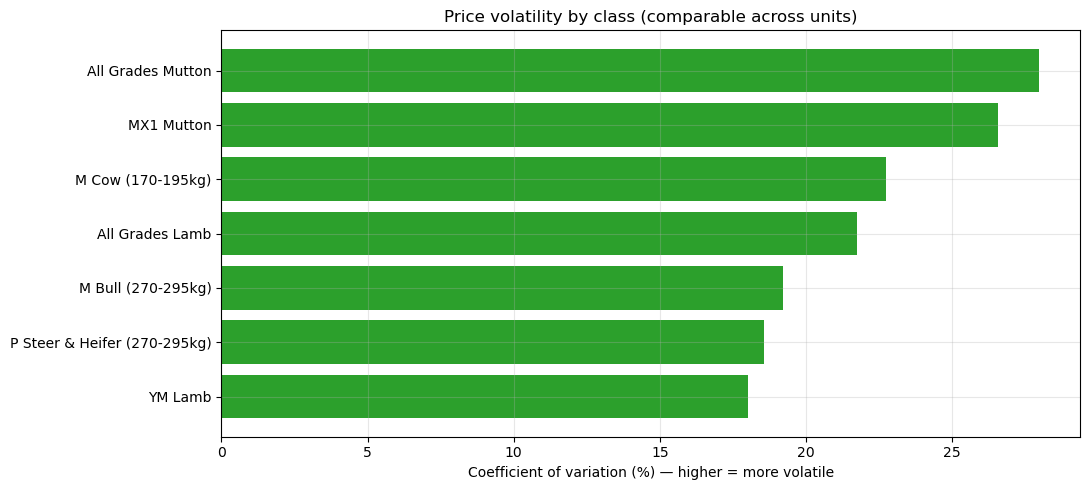

All Grades Mutton               28.0
MX1 Mutton                      26.6
M Cow (170-195kg)               22.7
All Grades Lamb                 21.7
M Bull (270-295kg)              19.2
P Steer & Heifer (270-295kg)    18.6
YM Lamb                         18.0
dtype: float64

In [27]:
# Volatility: coefficient of variation (std/mean) — comparable across units 
cv = (wide.std() / wide.mean() * 100).sort_values(ascending=False)
cv.index = [LABELS[i] for i in cv.index]
fig, ax = plt.subplots()
ax.barh(cv.index, cv.values, color='C2'); ax.invert_yaxis()
ax.set_xlabel('Coefficient of variation (%) — higher = more volatile')
ax.set_title('Price volatility by class (comparable across units)')
plt.tight_layout(); plt.show()
cv.round(1)

> **Finding:** The most volatile are Mutton and cows over the years. Mutton had the greatest dip in 2024 which is reflected here. There might be a correlation to the export demand. Lamb fluctuates predictable per season though is the most stable throughout the years. 

---
## Conclusion

This notebook explored two data foundations. Here is what each showed.

### PART A — Weather

**Q1 — How do the three regions differ, or are they the same?**
The regions share a clear seasonal rhythm in rainfall, temperature, and drying, but differ in magnitude: Taranaki runs consistently coolest and driest, Auckland warmest with the longest growing window, Waikato between. The Phase-2 t-test did not find the Taranaki–Auckland rainfall difference statistically significant (p = 0.4688), so on rainfall the regions are statistically alike — validating treating them as one North Island profile.

**Q2 — When does each region come under water stress?**
ET0 (water demand) follows a strong seasonal cycle, peaking in summer and bottoming in winter, while rainfall stays comparatively flat. The result is a summer pinch (months 1–2) where demand approaches or exceeds supply — exactly when pasture growth slows and feed tightens. This is the core signal PastureIQ flags.

**Q3 — Are dry years local or shared?**
The annual rainfall comparison showed the three regions moving together — shared dry years (2015, 2020) and wet years (2022, 2025). Drought is regional, not local, so feed pressure tends to arrive North-Island-wide at once.

### PART B — Market

**Q4 — Best and worst months to sell:** lambs — best month September, worst month February; seasonal swing ~12% (~$15/head), driven by the spring lamb-processing peak.

**Q5 — How the classes differ:**  — mutton most volatile in relative terms, YM lamb most stable — so timing matters more for mutton.

### How the two halves connect — the whole point of PastureIQ
Part A shows *when pasture tightens*; Part B shows *when prices are strong or weak*. The tool's value is combining them: feed pressure + strong price = a clear sell signal; feed pressure + weak price = a genuine trade-off to surface. The engineered weather features and the monthly price baselines built here are the direct inputs to that combined signal.

### Where this goes next
- **MP2:** connect weather to a pasture-growth model (→ kg DM/ha/day), combine with mob feed demand for a pasture-balance signal, and fold in these price signals via the buy/sell scoring.
- **MP3:** Prophet price-direction forecast on this history, plus the plain-English recommendation that is PastureIQ's end goal.

This notebook establishes that both foundations — weather and price — are complete, characterized, and carry the signals the tool depends on.